# Taller: Análisis de Instagram con Apify API + Gemini  

Fecha de generación: 2025-05-21


**Objetivos**

1. Obtener datos públicos de Instagram usando el actor **`apify/instagram-api-scraper`**.  
2. Limpiar y pre‑procesar captions e información de posts (descriptiva de los captions).  
3. Clasificar sentimiento de captions con la API de Google Generative AI (Gemini).  
4. Extraer temas dominantes con LDA y nombrarlos con Gemini. Crear Prompt
6. Diseñar una micro‑campaña basada en los insights descubiertos.


In [ ]:
import pandas as pd
import requests
import google.generativeai as palm

In [ ]:
# 🔑 Introduce tu token de Apify y de Google Generative AI (Gemini)
import os

In [ ]:
!wget https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/TercerCorte/instagram_disney.csv

--2025-11-27 23:36:42--  https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/TercerCorte/instagram_disney.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/TercerCorte/instagram_disney.csv [following]
--2025-11-27 23:36:43--  https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/TercerCorte/instagram_disney.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10377469 (9.9M) [text/plain]
Saving to: ‘instagram_disney.csv’

instagram_disney.cs 100%[===================>]  

In [ ]:
import pandas as pd

df = pd.read_csv("instagram_disney.csv")



### 🔍 Preguntas – Sección 1 (Exploración)
Mire las columnas de su dataset y responda
1. ¿Cuántos posts hay en total?  
2. ¿Qué tipos de contenido (imagen, vídeo, carrusel) predominan?  (mira la columna type)
3. ¿Cuál es el rango de fechas cubierto por los posts?  
4. ¿Qué post obtuvo más 'likes' y cuál crees que es la razón?


In [ ]:
df.shape

(200, 58)

In [ ]:
df.columns

Index(['inputUrl', 'id', 'username', 'url', 'fullName', 'biography',
       'externalUrls', 'followersCount', 'followsCount', 'hasChannel',
       'highlightReelCount', 'isBusinessAccount', 'joinedRecently',
       'businessCategoryName', 'private', 'verified', 'profilePicUrl',
       'profilePicUrlHD', 'igtvVideoCount', 'relatedProfiles',
       'latestIgtvVideos', 'postsCount', 'fbid', 'type', 'shortCode',
       'caption', 'hashtags', 'mentions', 'commentsCount', 'firstComment',
       'latestComments', 'dimensionsHeight', 'dimensionsWidth', 'displayUrl',
       'images', 'alt', 'likesCount', 'timestamp', 'childPosts',
       'ownerFullName', 'ownerUsername', 'ownerId', 'isSponsored',
       'isCommentsDisabled', 'videoUrl', 'videoViewCount', 'videoPlayCount',
       'productType', 'videoDuration', 'musicInfo.artist_name',
       'musicInfo.song_name', 'musicInfo.uses_original_audio',
       'musicInfo.should_mute_audio', 'musicInfo.should_mute_audio_reason',
       'musicInfo.audio

In [ ]:
df['type'].value_counts()

,count
type,
Video,83
Sidecar,67
Image,50


In [ ]:
from datetime import datetime
datetime.fromtimestamp(int())

datetime.datetime(1970, 1, 1, 0, 0)

In [ ]:
df["date"] = pd.to_datetime(df["timestamp"])

In [ ]:
df["date"].max()

Timestamp('2025-05-20 21:00:01+0000', tz='UTC')

In [ ]:
df["date"].min()

Timestamp('2024-03-16 17:00:01+0000', tz='UTC')

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df['likesCount'].sort_values(ascending=False)

,likesCount
85,558944
156,186613
109,136515
176,84230
167,81218
...,...
135,282
182,233
38,223
46,219


In [ ]:
df[df["likesCount"]==df["likesCount"].max()]

,inputUrl,id,username,url,fullName,biography,externalUrls,followersCount,followsCount,hasChannel,highlightReelCount,isBusinessAccount,joinedRecently,businessCategoryName,private,verified,profilePicUrl,profilePicUrlHD,igtvVideoCount,relatedProfiles,latestIgtvVideos,postsCount,fbid,type,shortCode,caption,hashtags,mentions,commentsCount,firstComment,latestComments,dimensionsHeight,dimensionsWidth,displayUrl,images,alt,likesCount,timestamp,childPosts,ownerFullName,ownerUsername,ownerId,isSponsored,isCommentsDisabled,videoUrl,videoViewCount,videoPlayCount,productType,videoDuration,musicInfo.artist_name,musicInfo.song_name,musicInfo.uses_original_audio,musicInfo.should_mute_audio,musicInfo.should_mute_audio_reason,musicInfo.audio_id,taggedUsers,coauthorProducers,isPinned,date
85,https://www.instagram.com/disneylat/,3506371026641991220,disneylat,https://www.instagram.com/p/DCpId8Ft7Y0/,Disney,La cuenta oficial de Disney para Latinoamérica.,[],569613,36,False,13,True,False,NaN,False,True,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,56,"[{'id': '65843594309', 'full_name': 'Universal...","[{'type': 'Video', 'shortCode': 'CippDnoLdX_',...",2331,17841403067929677,Video,DCpId8Ft7Y0,Llamando a la policía en 3...2...1....\n\n#Wif...,"['WifiRalph,']",['DisneyPlusLA.'],2182,😮😮,"[{'id': '17851745832417757', 'text': '😮😮', 'ow...",1920,1080,https://instagram.ftia8-1.fna.fbcdn.net/v/t51....,[],NaN,558944,2024-11-21T21:00:02.000Z,[],Disney,disneylat,2957422264,False,False,https://instagram.ftia8-1.fna.fbcdn.net/o1/v/t...,3371228.0,8006130.0,clips,43.066,disneylat,Original audio,True,False,NaN,1.920758e+15,NaN,NaN,NaN,2024-11-21 21:00:02+00:00



## 🧹 Sección 2 (Limpieza)

Explica por qué es importante limpiar y normalizar el texto de los captions.  
Entregue un grafico de barras con las frecuencia en los captions

In [ ]:
import re, nltk, string
nltk.download('stopwords')
from nltk.corpus import stopwords

def clean_caption(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)        # URLs
    text = re.sub(r"@[\w_]+", " ", text)        # Menciones
    text = re.sub(r"[#]", " ", text)             # Hashtags (opcional: conservar)
    text = re.sub(r"[{}]".format(string.punctuation), " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['caption_clean'] = df['caption'].fillna("").apply(clean_caption)
df[['caption', 'caption_clean']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,caption,caption_clean
0,"En cada imagen se esconde un Mickey, ¿puedes e...",en cada imagen se esconde un mickey ¿puedes en...
1,Esto se va a descontrolar.,esto se va a descontrolar
2,Los 2000 hechos canción. \n\nVuelve a ver #Liz...,los 2000 hechos canción vuelve a ver lizziemcg...
3,Con ser ella misma alcanzaba 🥹\n\n#Mulán dispo...,con ser ella misma alcanzaba 🥹 mulán disponibl...
4,"Llevábamos años esperando este momento, y no d...",llevábamos años esperando este momento y no de...


In [ ]:
df['caption_clean'].head()

,caption_clean
0,en cada imagen se esconde un mickey ¿puedes en...
1,esto se va a descontrolar
2,los 2000 hechos canción vuelve a ver lizziemcg...
3,con ser ella misma alcanzaba 🥹 mulán disponibl...
4,llevábamos años esperando este momento y no de...


In [ ]:
df["caption_limpio"] = df["caption"].apply(clean_caption)

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúüñ ]', '', texto)
    palabras = [palabra for palabra in texto.split() if palabra not in stopwords]
    return " ".join(palabras)

In [ ]:
df['clean_text'] = df['caption'].apply(limpiar_texto)

In [ ]:
todas_palabras = " ".join(df["clean_text"]).split()
frecuencias = Counter(todas_palabras)

freq_df = pd.DataFrame(frecuencias.items(), columns=["palabra", "frecuencia"])
freq_df = freq_df.sort_values(by="frecuencia", ascending=False).head(20)

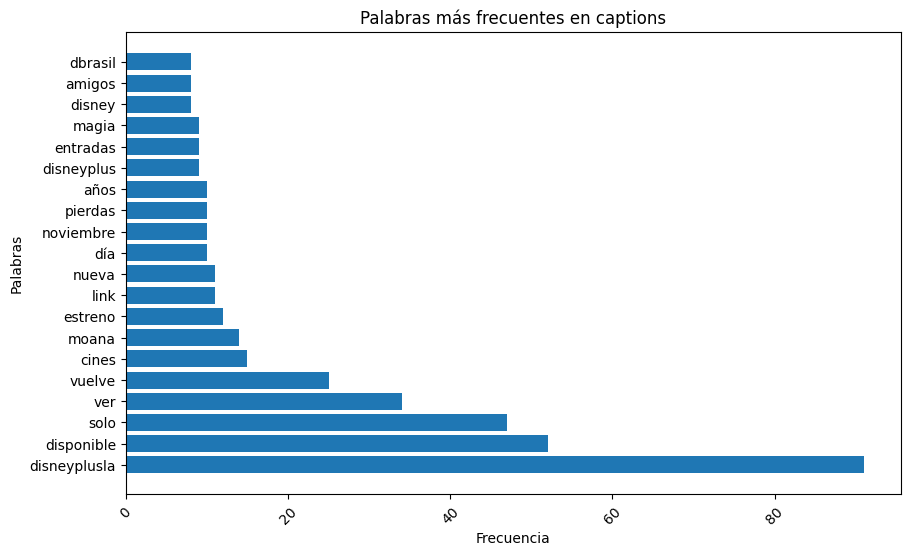

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(freq_df["palabra"], freq_df["frecuencia"])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en captions")
plt.ylabel("Palabras")
plt.xlabel("Frecuencia")
plt.show()


## 🗂 Sección 3 (Temas)
5. Pida a chatgpt o a una IA que le de 3 temas para clasificar un caption y denle un ejemplo.
6. Escriba un prompt en donde le pida clasificar un caption y que de respuesta solo regrese una palabra.
7. Apliquelo en toda la columna caption creando una columna topics.

10. Lista los nombres de los temas generados. ¿Alguno es inesperado?  
11. Con un heatmap *tipo de contenido × tema*, indica qué tema es “propiedad” de cada formato.  
12. Para el tema dominante, proporciona dos insights accionables.


In [ ]:
import os
os.environ["OPENAI_API_KEY"] =
from openai import OpenAI

client = OpenAI()

In [ ]:
df.head()

,inputUrl,id,username,url,fullName,biography,externalUrls,followersCount,followsCount,hasChannel,highlightReelCount,isBusinessAccount,joinedRecently,businessCategoryName,private,verified,profilePicUrl,profilePicUrlHD,igtvVideoCount,relatedProfiles,latestIgtvVideos,postsCount,fbid,type,shortCode,caption,hashtags,mentions,commentsCount,firstComment,latestComments,dimensionsHeight,dimensionsWidth,displayUrl,images,alt,likesCount,timestamp,childPosts,ownerFullName,ownerUsername,ownerId,isSponsored,isCommentsDisabled,videoUrl,videoViewCount,videoPlayCount,productType,videoDuration,musicInfo.artist_name,musicInfo.song_name,musicInfo.uses_original_audio,musicInfo.should_mute_audio,musicInfo.should_mute_audio_reason,musicInfo.audio_id,taggedUsers,coauthorProducers,isPinned,date,caption_clean,caption_limpio,clean_text
0,https://www.instagram.com/disneylat/,3626608212947059675,disneylat,https://www.instagram.com/p/DJUTPSAOUPb/,Disney,La cuenta oficial de Disney para Latinoamérica.,[],569613,36,False,13,True,False,NaN,False,True,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,56,"[{'id': '65843594309', 'full_name': 'Universal...","[{'type': 'Video', 'shortCode': 'CippDnoLdX_',...",2331,17841403067929677,Sidecar,DJUTPSAOUPb,"En cada imagen se esconde un Mickey, ¿puedes e...",[],['DisneyPlusLA.'],37,Muy fáciles !!! Mis ojos están acostumbrados a...,"[{'id': '18047732783593444', 'text': ""Muy fáci...",1080,1080,https://instagram.fman2-1.fna.fbcdn.net/v/t51....,['https://instagram.fman2-1.fna.fbcdn.net/v/t5...,"Photo by Disney on May 06, 2025. May be a cart...",3757,2025-05-06T15:30:13.000Z,"[{'id': '3626608162817065682', 'type': 'Image'...",Disney,disneylat,2957422264,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-06 15:30:13+00:00,en cada imagen se esconde un mickey ¿puedes en...,en cada imagen se esconde un mickey ¿puedes en...,cada imagen esconde mickey puedes encontrarlos...
1,https://www.instagram.com/disneylat/,3636752063146304692,disneylat,https://www.instagram.com/p/DJ4VrusASS0/,Disney,La cuenta oficial de Disney para Latinoamérica.,[],569613,36,False,13,True,False,NaN,False,True,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,56,"[{'id': '65843594309', 'full_name': 'Universal...","[{'type': 'Video', 'shortCode': 'CippDnoLdX_',...",2331,17841403067929677,Sidecar,DJ4VrusASS0,Esto se va a descontrolar.,[],[],4,Lei en una noticia que suspieron a sus trabaja...,"[{'id': '18086294593629417', 'text': 'Lei en u...",1350,1080,https://scontent-man2-1.cdninstagram.com/v/t51...,['https://scontent-man2-1.cdninstagram.com/v/t...,"Photo by Disney on May 20, 2025. May be a cart...",1102,2025-05-20T21:00:01.000Z,"[{'id': '3636751996549205806', 'type': 'Image'...",Disney,disneylat,2957422264,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-20 21:00:01+00:00,esto se va a descontrolar,esto se va a descontrolar,va descontrolar
2,https://www.instagram.com/disneylat/,3629059382491345626,disneylat,https://www.instagram.com/p/DJdAkfiMfLa/,Disney,La cuenta oficial de Disney para Latinoamérica.,[],569613,36,False,13,True,False,NaN,False,True,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,https://instagram.flfw1-1.fna.fbcdn.net/v/t51....,56,"[{'id': '65843594309', 'full_name': 'Universal...","[{'type': 'Video', 'shortCode': 'CippDnoLdX_',...",2331,17841403067929677,Video,DJdAkfiMfLa,Los 2000 hechos canción. \n\nVuelve a ver #Liz...,['LizzieMcguire:'],['DisneyPlusLA.'],38,Ella siempre fue mi favorita he vistos todas l...,"[{'id': '18066782120055672', 'text': 'Ella sie...",1920,1080,https://instagram.fjsr6-1.fna.fbcdn.net/v/t51....,[],NaN,5379,2025-05-10T16:30:03.000Z,[],Disney,disneylat,2957422264,False,False,https://instagram.fjsr6-1.fna.fbcdn.net/o1/v/t...,0.0,69690.0,clips,59.179,sacqspot,Original audio,True,False,NaN,6.053466e+14,NaN,NaN,NaN,2025-05-10 16:30:03+00:00,los 2000 hechos canción vuelv

In [ ]:
import requests
import json

In [ ]:
import os
os.environ["OPENAI_API_KEY"] =

from openai import OpenAI

client = OpenAI()

In [ ]:
from openai import OpenAI

client = OpenAI()


In [ ]:
def suma(a,b):
 return a+b

In [ ]:
suma(5,10)

15

In [ ]:
def call_llm(prompt):
  response = client.responses.create(
  model="gpt-4o-mini",
  input=prompt
)
  return response.output_text



In [ ]:
call_llm("dame 3 temas para clasificar un caption")

'Claro, aquí tienes tres temas para clasificar un caption:\n\n1. **Inspiración y Motivación**: Frases o citas que impulsan a la acción, reflexiones sobre la vida o el éxito.\n\n2. **Naturaleza y Aventura**: Descripciones sobre paisajes, actividades al aire libre o experiencias únicas en la naturaleza.\n\n3. **Relaciones y Conexiones**: Contenidos que hablen sobre la amistad, el amor, la familia o momentos compartidos con seres queridos. \n\nSi necesitas ayuda con algo más específico, ¡házmelo saber!'

In [ ]:
def classify_topics(text):
  prompt = (f"Clasifica por tematicas el siguiente caption:{text} "
              f"solo tienes entre estos Inspiración_Motivación, Naturaleza_Viajes, Vida Cotidiana_Reflexiones. solo responde con una palabra")
  try:
    respuesta = call_llm(prompt)
  except:
    respuesta = "deafult"
  return respuesta

In [ ]:
sample = df.sample(10, replace = True ,random_state=42)
sample['caption'] = sample['caption_clean'].apply(classify_topics)

In [ ]:
sample['caption'].value_counts()

,count
caption,
Inspiración_Motivación,4
Vida Cotidiana_Reflexiones,4
Vida Cotidiana_Reflexiones.,2


In [ ]:
pd.crosstab(sample['caption'], sample['type'])

type,Image,Sidecar,Video
caption,,,
Inspiración_Motivación,0,1,3
Vida Cotidiana_Reflexiones,1,2,1
Vida Cotidiana_Reflexiones.,1,0,1


<Axes: xlabel='type', ylabel='caption'>

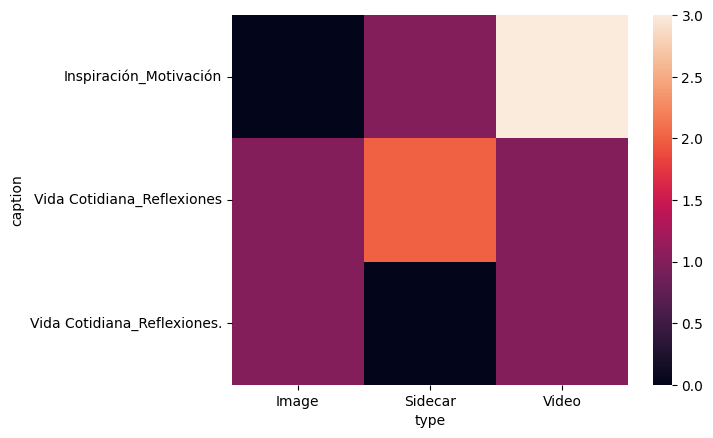

In [ ]:
import seaborn as sns
sns.heatmap(pd.crosstab(sample['caption'], sample['type']))



## 📝 Sección 4 (Micro‑campaña)

Cree una columna para una publicidad especifica:


In [ ]:
import pandas as pd

# Lista de diccionarios con la información
datos = [
    {"Nombre": "Ana Torres", "Personaje de Interés": "Estudiante universitaria", "Rango de Edad": "18-24", "Producto a Vender": "Laptop económica"},
    {"Nombre": "Carlos Pérez", "Personaje de Interés": "Emprendedor digital", "Rango de Edad": "25-34", "Producto a Vender": "Software de productividad"},
    {"Nombre": "Lucía Gómez", "Personaje de Interés": "Madre primeriza", "Rango de Edad": "25-34", "Producto a Vender": "Pañales ecológicos"},
    {"Nombre": "Marco Díaz", "Personaje de Interés": "Gamer profesional", "Rango de Edad": "18-24", "Producto a Vender": "Silla ergonómica para gaming"},
    {"Nombre": "Teresa Ríos", "Personaje de Interés": "Ejecutiva de marketing", "Rango de Edad": "35-44", "Producto a Vender": "Cursos de liderazgo online"},
    {"Nombre": "Andrés López", "Personaje de Interés": "Jubilado activo", "Rango de Edad": "65-74", "Producto a Vender": "Viajes culturales guiados"},
    {"Nombre": "Valentina Cruz", "Personaje de Interés": "Influencer de moda", "Rango de Edad": "18-24", "Producto a Vender": "Ropa de diseñador"},
    {"Nombre": "Roberto Silva", "Personaje de Interés": "Dueño de cafetería", "Rango de Edad": "35-44", "Producto a Vender": "Cafetera industrial"},
    {"Nombre": "Elena Fuentes", "Personaje de Interés": "Freelance creativa", "Rango de Edad": "25-34", "Producto a Vender": "Tableta gráfica"},
    {"Nombre": "Javier Ramírez", "Personaje de Interés": "Papá de familia numerosa", "Rango de Edad": "35-44", "Producto a Vender": "Plan de supermercado online"}
]

# Crear el DataFrame
df = pd.DataFrame(datos)

In [ ]:
df

,Nombre,Personaje de Interés,Rango de Edad,Producto a Vender
0,Ana Torres,Estudiante universitaria,18-24,Laptop económica
1,Carlos Pérez,Emprendedor digital,25-34,Software de productividad
2,Lucía Gómez,Madre primeriza,25-34,Pañales ecológicos
3,Marco Díaz,Gamer profesional,18-24,Silla ergonómica para gaming
4,Teresa Ríos,Ejecutiva de marketing,35-44,Cursos de liderazgo online
5,Andrés López,Jubilado activo,65-74,Viajes culturales guiados
6,Valentina Cruz,Influencer de moda,18-24,Ropa de diseñador
7,Roberto Silva,Dueño de cafetería,35-44,Cafetera industrial
8,Elena Fuentes,Freelance creativa,25-34,Tableta gráfica
9,Javier Ramírez,Papá de familia numerosa,35-44,Plan de supermercado online


In [ ]:
def generar_caption(nombre, topic, personaje, publico):
    prompt = (f"Actúa como community manager. Crea un caption de máximo 220 caracteres, el objetivo es motivarlo a comprar"
              f"para la persona : {nombre } sobre el tema '{topic}' y el personaje {personaje} para un publico de {publico} años.No incluyas hashtags ni menciones.")
    response = call_llm(prompt)
    return response



In [ ]:
# Extraemos los valores y aplicamos la función para crear la nueva columna
df['Caption'] = df.apply(lambda row: generar_caption(
    nombre=row['Nombre'],
    topic=row['Producto a Vender'],
    personaje=row['Personaje de Interés'],
    publico=row['Rango de Edad']
), axis=1)

In [ ]:
df.head()

,Nombre,Personaje de Interés,Rango de Edad,Producto a Vender,Caption
0,Ana Torres,Estudiante universitaria,18-24,Laptop económica,"¡Ana, tu mejor aliado para estudiar está aquí!..."
1,Carlos Pérez,Emprendedor digital,25-34,Software de productividad,¿Listo para llevar tu emprendimiento al siguie...
2,Lucía Gómez,Madre primeriza,25-34,Pañales ecológicos,"Lucía, como madre primeriza, sabes lo importan..."
3,Marco Díaz,Gamer profesional,18-24,Silla ergonómica para gaming,¡Transforma tu juego con la silla ergonómica p...
4,Teresa Ríos,Ejecutiva de marketing,35-44,Cursos de liderazgo online,Transforma tu carrera con nuestros cursos de l...
